# WM-811K Wafer Map — Model 4: KL-divergence to class-average heatmaps

Idea: build one **average defect heatmap per class** from the training set (same as in `EDA.ipynb`), treat each heatmap as a probability distribution over pixels, and classify any wafer map by picking the class whose prototype has the **smallest KL divergence** to the (flattened, normalized) wafer map. No learnable parameters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

## 1. Load the data

In [2]:
import pickle
import sys

# Patch old pandas module paths for compatibility (pickle was saved with pandas < 0.20)
_compat_map = {
    'pandas.indexes':         'pandas.core.indexes',
    'pandas.indexes.base':    'pandas.core.indexes.base',
    'pandas.indexes.numeric': 'pandas.core.indexes.base',
    'pandas.indexes.range':   'pandas.core.indexes.range_',
    'pandas.indexes.multi':   'pandas.core.indexes.multi',
    'pandas.indexes.frozen':  'pandas.core.indexes.frozen',
}

for old, new in _compat_map.items():
    try:
        sys.modules[old] = __import__(new, fromlist=[''])
    except ImportError:
        pass

class _CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        for old, new in _compat_map.items():
            if module.startswith(old):
                module = module.replace(old, new, 1)
                break
        return super().find_class(module, name)

with open('./Data/LSWMD.pkl', 'rb') as f:
    try:
        df = pickle.load(f, encoding='latin1')
    except (ModuleNotFoundError, ImportError):
        f.seek(0)
        df = _CompatUnpickler(f)
        df.encoding = 'latin1'
        df = df.load()

print(f'Shape: {df.shape}')
df.head()

/tmp/ipykernel_4101185/3958013367.py:30: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  df = pickle.load(f, encoding='latin1')


Shape: (811457, 6)


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


## 2. Extract labels and filter out unknown failure types

In [3]:
def extract_label(x):
    if isinstance(x, (list, np.ndarray)):
        flat = np.array(x).flatten()
        if len(flat) > 0:
            return str(flat[0])
    if isinstance(x, str):
        return x
    return 'unknown'

df['failure_label'] = df['failureType'].apply(extract_label)
df_labeled = df[~df['failure_label'].isin(['unknown', ''])].reset_index(drop=True)

print(f'Before filter: {len(df):,}')
print(f'After filter:  {len(df_labeled):,}')
print('\nClass counts:')
print(df_labeled['failure_label'].value_counts())

Before filter: 811,457
After filter:  172,950

Class counts:
failure_label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


## 3. Stratified 60 / 20 / 20 split (same as `model1.ipynb`)

In [4]:
classes = sorted(df_labeled['failure_label'].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
NUM_CLASSES = len(classes)
print(f'{NUM_CLASSES} classes: {classes}')

df_labeled['label_idx'] = df_labeled['failure_label'].map(class_to_idx)

y = df_labeled['label_idx'].values
idx_all = np.arange(len(df_labeled))

idx_trainval, idx_test = train_test_split(
    idx_all, test_size=0.20, stratify=y, random_state=SEED
)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.25, stratify=y[idx_trainval], random_state=SEED
)

print(f'\nTrain: {len(idx_train):,}  ({len(idx_train)/len(idx_all):.1%})')
print(f'Val:   {len(idx_val):,}  ({len(idx_val)/len(idx_all):.1%})')
print(f'Test:  {len(idx_test):,}  ({len(idx_test)/len(idx_all):.1%})')

9 classes: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']

Train: 103,770  (60.0%)
Val:   34,590  (20.0%)
Test:  34,590  (20.0%)


## 4. Resize all wafer maps to a common 64×64 grid

Same recipe as `EDA.ipynb` and `model1.ipynb`: nearest-neighbor resize so the discrete `0/1/2` codes are preserved (`0` = background, `1` = normal die, `2` = defective die).

In [5]:
IMG_SIZE = 64

def resize_wafer(wmap, target=IMG_SIZE):
    wmap = np.asarray(wmap)
    if wmap.ndim < 2 or wmap.shape[0] == 0 or wmap.shape[1] == 0:
        return np.zeros((target, target), dtype=np.float32)
    h, w = wmap.shape
    return zoom(wmap, (target / h, target / w), order=0).astype(np.float32)

def stack_resized(indices):
    out = np.empty((len(indices), IMG_SIZE, IMG_SIZE), dtype=np.float32)
    maps = df_labeled['waferMap'].values
    for k, i in enumerate(indices):
        out[k] = resize_wafer(maps[i])
    return out

X_train = stack_resized(idx_train)
X_test  = stack_resized(idx_test)
y_train = df_labeled['label_idx'].values[idx_train]
y_test  = df_labeled['label_idx'].values[idx_test]

print(f'X_train: {X_train.shape}  X_test: {X_test.shape}')

X_train: (103770, 64, 64)  X_test: (34590, 64, 64)


## 5. Average defect heatmaps per class (computed on training set)

For each of the 9 classes, average the resized wafer maps belonging to that class — same procedure as Section 8 of `EDA.ipynb`. The result is a 64×64 image whose intensity at each pixel is the mean `0/1/2` code at that location, i.e. "how typical is it for this pixel to be defective in this class".

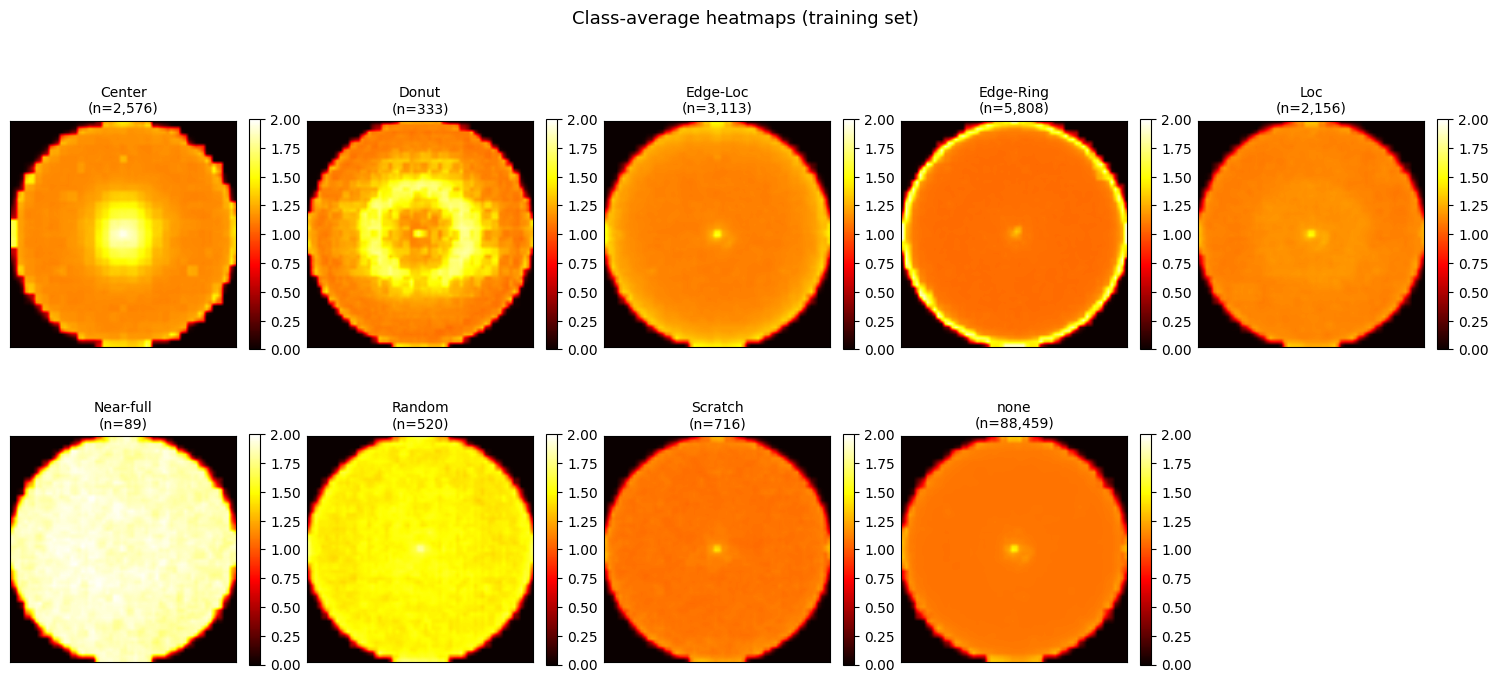

In [6]:
heatmaps = np.zeros((NUM_CLASSES, IMG_SIZE, IMG_SIZE), dtype=np.float32)
for c in range(NUM_CLASSES):
    mask = (y_train == c)
    heatmaps[c] = X_train[mask].mean(axis=0)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()
for c in range(NUM_CLASSES):
    im = axes[c].imshow(heatmaps[c], cmap='hot', vmin=0, vmax=2, interpolation='bilinear')
    axes[c].set_title(f'{idx_to_class[c]}\n(n={(y_train==c).sum():,})', fontsize=10)
    axes[c].set_xticks([]); axes[c].set_yticks([])
    plt.colorbar(im, ax=axes[c], fraction=0.046)
for j in range(NUM_CLASSES, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Class-average heatmaps (training set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Convert heatmaps and images to probability distributions, then classify by min-KL

**Setup.** Flatten each 64×64 array to a 4096-vector. To get a valid probability distribution we add a small `eps` (avoids `log(0)`) and divide by the sum.

**Decision rule.** For an image `p` and a class prototype `q_c`, we use
$$\mathrm{KL}(p \,\Vert\, q_c) \;=\; \sum_i p_i \log \frac{p_i}{q_{c,i}}$$
and predict $\arg\min_c \mathrm{KL}(p \Vert q_c)$. Argmin of KL with a fixed `p` is equivalent to argmax of $\sum_i p_i \log q_{c,i}$, i.e. the cross-entropy form — we compute it in that vectorized form for speed.

In [7]:
EPS = 1e-6

def to_distribution(arr):
    """Flatten last two dims, add eps, normalize to sum=1 along last axis."""
    flat = arr.reshape(arr.shape[0], -1).astype(np.float64) + EPS
    flat /= flat.sum(axis=1, keepdims=True)
    return flat

# Class prototypes: (NUM_CLASSES, 4096)
Q = to_distribution(heatmaps)
log_Q = np.log(Q)

def kl_predict(X):
    """Predict labels for a stack of resized wafer maps via min KL(p || q_c).

    KL(p || q) = sum p log p - sum p log q. The first term is identical across
    classes, so argmin_c KL = argmax_c (p . log_q[c]).
    """
    P = to_distribution(X)               # (N, 4096)
    cross = P @ log_Q.T                  # (N, NUM_CLASSES) = sum_i p_i log q_{c,i}
    p_logp = (P * np.log(P)).sum(axis=1, keepdims=True)
    kl = p_logp - cross                  # (N, NUM_CLASSES)
    return kl.argmin(axis=1), kl

y_train_pred, kl_train = kl_predict(X_train)
y_test_pred,  kl_test  = kl_predict(X_test)

print(f'train accuracy: {(y_train_pred == y_train).mean():.4f}')
print(f'test  accuracy: {(y_test_pred  == y_test ).mean():.4f}')

train accuracy: 0.3463
test  accuracy: 0.3476


## 7. Test-set evaluation (same metrics as the other models)

In [8]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, cohen_kappa_score,
)

y_true = y_test
y_pred = y_test_pred
target_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

print(f'Test samples: {len(y_true):,}')
print(f'\nAccuracy:           {accuracy_score(y_true, y_pred):.4f}')
print(f'Balanced accuracy:  {balanced_accuracy_score(y_true, y_pred):.4f}  (mean per-class recall)')
print(f"Cohen's kappa:      {cohen_kappa_score(y_true, y_pred):.4f}")
for avg in ('macro', 'weighted'):
    p = precision_score(y_true, y_pred, average=avg, zero_division=0)
    r = recall_score(   y_true, y_pred, average=avg, zero_division=0)
    f = f1_score(       y_true, y_pred, average=avg, zero_division=0)
    print(f'{avg:>8s}: precision {p:.4f}  recall {r:.4f}  f1 {f:.4f}')

print('\nPer-class report:')
print(classification_report(y_true, y_pred, target_names=target_names,
                            digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
print('Confusion matrix (rows=true, cols=predicted):')
cm_df

Test samples: 34,590

Accuracy:           0.3476
Balanced accuracy:  0.4782  (mean per-class recall)
Cohen's kappa:      0.1367
   macro: precision 0.3643  recall 0.4782  f1 0.3085
weighted: precision 0.8990  recall 0.3476  f1 0.4777

Per-class report:
              precision    recall  f1-score   support

      Center     0.8437    0.5530    0.6681       859
       Donut     0.1898    0.8378    0.3095       111
    Edge-Loc     0.2747    0.3622    0.3124      1038
   Edge-Ring     0.9186    0.8399    0.8775      1936
         Loc     0.0618    0.1003    0.0765       718
   Near-full     0.0053    0.3000    0.0105        30
      Random     0.0168    0.3642    0.0322       173
     Scratch     0.0107    0.6360    0.0210       239
        none     0.9576    0.3105    0.4690     29486

    accuracy                         0.3476     34590
   macro avg     0.3643    0.4782    0.3085     34590
weighted avg     0.8990    0.3476    0.4777     34590

Confusion matrix (rows=true, cols=predicte

,Center,Donut,Edge-Loc,Edge-Ring,Loc,Near-full,Random,Scratch,none
Center,475,62,3,7,23,6,81,158,44
Donut,1,93,0,0,0,0,2,13,2
Edge-Loc,46,6,376,12,42,28,69,322,137
Edge-Ring,3,0,144,1626,1,5,8,111,38
Loc,27,80,19,0,72,26,79,299,116
Near-full,0,3,0,1,0,9,0,7,10
Random,6,21,3,4,13,4,63,29,30
Scratch,3,0,7,2,14,9,24,152,28
none,2,225,817,118,1000,1599,3416,13153,9156
